# Week1_ex2 Analysis — Why Line 2-3 Loading Differs Between PowerWorld and pandapower

Deep dive on the one mismatch left in `Week1_ex2`: every bus voltage and line flow agrees, but line 2-3 reads 8.4 % in PowerWorld and 8.61 % in pandapower. The two tools define loading differently:

$$\text{PowerWorld: } L_S = \frac{\max(S_{from}, S_{to})}{S_{lim}} \qquad \text{pandapower: } L_I = \frac{I}{I_{max}}, \quad I_{max} = \frac{S_{lim}}{\sqrt{3}\,V_{nom}}$$

With no line charging (B = 0) the current is the same at both ends, and $S = \sqrt{3}\,V I$, so

$$\frac{L_I}{L_S} = \frac{1}{\max(V_{from}, V_{to})\ [\text{pu}]}$$

The two only agree when the higher-voltage end sits at 1.0 pu.

In [1]:
import numpy as np
import pandas as pd
import pandapower as pp
import pandapower.topology as top

# 1. Per-unit bases used by the PowerWorld case
S_BASE_MVA = 100.0                      # back-calculated: I = 0.05 pu, I^2 R = 0.00075 pu = 0.075 MW only on 100 MVA
V_BASE_KV = 16.0                        # nominal voltage of every bus
Z_BASE_OHM = V_BASE_KV**2 / S_BASE_MVA  # 2.56 ohm

# 2. Line data read once from PowerWorld Simulator (Run Mode, Model Explorer > Network > Branches Input)
R_PU, X_PU, B_PU = 0.30, 0.60, 0.0
LIM_MVA = 20.0

# 3. Convert per-unit impedance to pandapower inputs (length fixed at 1 km, so ohm/km = ohm)
r_ohm = R_PU * Z_BASE_OHM
x_ohm = X_PU * Z_BASE_OHM
max_i_ka = LIM_MVA / (np.sqrt(3) * V_BASE_KV)   # MVA rating -> current rating at nominal voltage

pd.DataFrame({
    "Quantity": ["Z_base [ohm]", "R [ohm]", "X [ohm]", "I_max [kA]"],
    "Value": [Z_BASE_OHM, r_ohm, x_ohm, max_i_ka],
}).round(4)

,Quantity,Value
0,Z_base [ohm],2.5600
1,R [ohm],0.7680
2,X [ohm],1.5360
3,I_max [kA],0.7217


In [2]:
# 4. Build the network: three identical lines forming a loop, loads at Bus 2 and Bus 3
net = pp.create_empty_network(f_hz=60, sn_mva=S_BASE_MVA)
buses = [pp.create_bus(net, V_BASE_KV, name=f"Bus {i}") for i in (1, 2, 3)]
pp.create_ext_grid(net, buses[0], vm_pu=1.0)
for f, t in [(0, 1), (0, 2), (1, 2)]:
    pp.create_line_from_parameters(net, buses[f], buses[t], length_km=1.0, r_ohm_per_km=r_ohm,
                                   x_ohm_per_km=x_ohm, c_nf_per_km=0.0, max_i_ka=max_i_ka,
                                   name=f"{f + 1}-{t + 1}")
pp.create_load(net, buses[1], p_mw=5.0, q_mvar=0.0)
pp.create_load(net, buses[2], p_mw=10.0, q_mvar=0.0)

# 5. Solve
pp.runpp(net, numba=False)

# 6. Measured: PowerWorld loading (Branches State, % of MVA Limit (Max)) vs pandapower loading_percent
pw_loading = np.array([34.2, 42.8, 8.4])
pd.DataFrame({
    "Line": net.line.name,
    "PowerWorld [%]": pw_loading,
    "pandapower [%]": net.res_line.loading_percent,
    "Diff [%-pt]": net.res_line.loading_percent - pw_loading,
}).round(3)

,Line,PowerWorld [%],pandapower [%],Diff [%-pt]
0,1-2,34.2,34.160,-0.040
1,1-3,42.8,42.770,-0.030
2,2-3,8.4,8.611,0.211


In [3]:
# 7. Theory vs measured: rebuild both definitions from the same pandapower solution
def loading_both(net):
    r = net.res_line
    s_max = np.maximum(np.hypot(r.p_from_mw, r.q_from_mvar), np.hypot(r.p_to_mw, r.q_to_mvar))
    v = net.res_bus.vm_pu.values
    v_hi = np.maximum(v[net.line.from_bus.values], v[net.line.to_bus.values])
    return s_max / LIM_MVA * 100, r.loading_percent.values, 1 / v_hi

l_s, l_i, ratio_theory = loading_both(net)
check = pd.DataFrame({
    "Line": net.line.name,
    "MVA-based [%]": l_s,
    "Current-based [%]": l_i,
    "Observed ratio": l_i / l_s,
    "Theory 1/max(V)": ratio_theory,
})
check["Ratio error"] = check["Observed ratio"] - check["Theory 1/max(V)"]
assert check["Ratio error"].abs().max() < 1e-9
check.round(4)

,Line,MVA-based [%],Current-based [%],Observed ratio,Theory 1/max(V),Ratio error
0,1-2,34.1602,34.1602,1.000,1.000,-0.0
1,1-3,42.7704,42.7704,1.000,1.000,0.0
2,2-3,8.4255,8.6110,1.022,1.022,0.0


## Hypothesis 1 — the gap is purely a definition difference

If the tools solved the same physics, rebuilding PowerWorld's MVA-based loading from the pandapower solution should land on PowerWorld's numbers, and the ratio between the two definitions should equal $1/\max(V)$ exactly.

**Verdict: accepted.** The MVA-based values (34.16 / 42.77 / 8.43 %) match PowerWorld to its display precision, and the observed ratio equals $1/\max(V)$ to machine precision. Lines 1-2 and 1-3 agree only because one end is the slack bus held at 1.0 pu.

In [4]:
# 8. Sweep both loads up together and record line 2-3 under each definition
rows = []
for k in np.arange(1.0, 6.01, 0.25):
    net.load["scaling"] = k
    pp.runpp(net, numba=False)
    l_s, l_i, ratio_theory = loading_both(net)
    rows.append({
        "Load scale": k,
        "Total load [MW]": 15.0 * k,
        "Min bus voltage [pu]": net.res_bus.vm_pu.min(),
        "Line 2-3 MVA-based [%]": l_s[2],
        "Line 2-3 current-based [%]": l_i[2],
        "Line 1-3 gap [%-pt]": l_i[1] - l_s[1],
        "Line 2-3 theory gap [%]": (ratio_theory[2] - 1) * 100,
    })
net.load["scaling"] = 1.0
pp.runpp(net, numba=False)   # restore the base-case solution for the cells below
sweep = pd.DataFrame(rows)
sweep["Line 2-3 gap [%]"] = (sweep["Line 2-3 current-based [%]"] / sweep["Line 2-3 MVA-based [%]"] - 1) * 100
assert (sweep["Line 2-3 gap [%]"] - sweep["Line 2-3 theory gap [%]"]).abs().max() < 1e-9
sweep.round(3)

,Load scale,Total load [MW],Min bus voltage [pu],Line 2-3 MVA-based [%],Line 2-3 current-based [%],Line 1-3 gap [%-pt],Line 2-3 theory gap [%],Line 2-3 gap [%]
0,1.00,15.00,0.973,8.425,8.611,0.0,2.202,2.202
1,1.25,18.75,0.966,10.565,10.863,0.0,2.824,2.824
2,1.50,22.50,0.958,12.719,13.162,0.0,3.478,3.478
3,1.75,26.25,0.950,14.890,15.511,0.0,4.168,4.168
4,2.00,30.00,0.942,17.080,17.917,0.0,4.897,4.897
5,2.25,33.75,0.933,19.290,20.384,0.0,5.669,5.669
6,2.50,37.50,0.924,21.522,22.919,0.0,6.487,6.487
7,2.75,41.25,0.915,23.780,25.529,0.0,7.356,7.356
8,3.00,45.00,0.905,26.065,28.224,0.0,8.284,8.284
9,3.25,48.75,0.894,28.381,31.014,-0.0,9.276,9.276


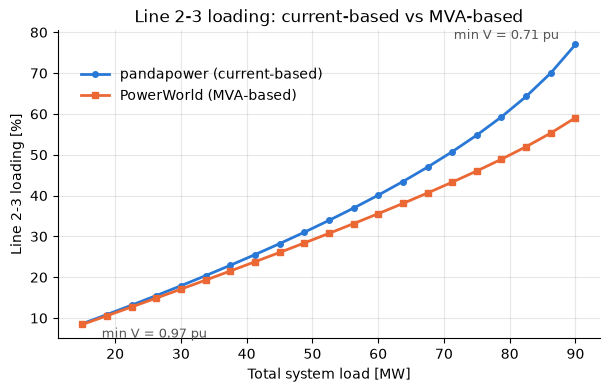

In [5]:
import matplotlib.pyplot as plt

# 9. Plot line 2-3 loading under both definitions against total system load
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep["Total load [MW]"], sweep["Line 2-3 current-based [%]"], color="#2a78d6", lw=2,
        marker="o", ms=4, label="pandapower (current-based)")
ax.plot(sweep["Total load [MW]"], sweep["Line 2-3 MVA-based [%]"], color="#eb6834", lw=2,
        marker="s", ms=4, label="PowerWorld (MVA-based)")
for idx, offset, ha in [(0, (14, -10), "left"), (-1, (-12, 4), "right")]:
    row = sweep.iloc[idx]
    ax.annotate(f"min V = {row['Min bus voltage [pu]']:.2f} pu",
                (row["Total load [MW]"], row["Line 2-3 current-based [%]"]),
                textcoords="offset points", xytext=offset, ha=ha, fontsize=9, color="#555555")
ax.set_xlabel("Total system load [MW]")
ax.set_ylabel("Line 2-3 loading [%]")
ax.set_title("Line 2-3 loading: current-based vs MVA-based")
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.02, 0.92))
fig.savefig("Images/Week1_ex2_loading_definition_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# 10. Gap at a few voltage levels a planner would care about
marks = sweep.iloc[[0, 4, 8, 12, -1]]
marks[["Total load [MW]", "Min bus voltage [pu]", "Line 2-3 MVA-based [%]",
       "Line 2-3 current-based [%]", "Line 2-3 gap [%]", "Line 2-3 theory gap [%]", "Line 1-3 gap [%-pt]"]].round(3)

,Total load [MW],Min bus voltage [pu],Line 2-3 MVA-based [%],Line 2-3 current-based [%],Line 2-3 gap [%],Line 2-3 theory gap [%],Line 1-3 gap [%-pt]
0,15.0,0.973,8.425,8.611,2.202,2.202,0.0
4,30.0,0.942,17.080,17.917,4.897,4.897,0.0
8,45.0,0.905,26.065,28.224,8.284,8.284,0.0
12,60.0,0.859,35.568,40.097,12.733,12.733,0.0
20,90.0,0.707,59.075,77.009,30.357,30.357,0.0


## Hypothesis 2 — the gap grows as voltage sags, but only on lines away from a held bus

From the formula, the current-based reading should run ahead of the MVA-based one by $1/\max(V) - 1$, where $\max(V)$ is the line's higher end voltage: about 5 % at 0.95 pu and about 11 % at 0.90 pu. Lines with one end at the slack bus should never diverge.

**Verdict: accepted.** Line 2-3 opens a gap that matches $1/\max(V) - 1$ to machine precision across the whole sweep, from 2.2 % at base load to 30 % when the system is pushed to 0.71 pu, while line 1-3 stays at a zero gap even when it runs far past its rating.

In [7]:
# 11. Appendix: AC flows vs a lossless DC power flow (DC split is set by reactances alone)
import copy

net_dc = copy.deepcopy(net)
pp.rundcpp(net_dc, numba=False)
flow_split = pd.DataFrame({
    "Line": net.line.name,
    "AC P from [MW]": net.res_line.p_from_mw,
    "DC P from [MW]": net_dc.res_line.p_from_mw,
})
flow_split["Diff [MW]"] = flow_split["AC P from [MW]"] - flow_split["DC P from [MW]"]
flow_split.round(3)

,Line,AC P from [MW],DC P from [MW],Diff [MW]
0,1-2,6.825,6.667,0.158
1,1-3,8.544,8.333,0.210
2,2-3,1.685,1.667,0.018


## Final conclusion

The 8.4 % vs 8.61 % mismatch on line 2-3 is not a modelling error: both tools solve the same flows, and the gap is exactly the factor $1/\max(V)$ between an MVA-based and a current-based loading. Because a conductor's thermal limit is set by current, the MVA-based figure understates loading whenever both ends sag below 1.0 pu, by roughly 5 % when the line's higher end sits at 0.95 pu and 11 % at 0.90 pu. That is the regime a heat-wave or N-1 study runs in, so the pipeline keeps pandapower's current-based `loading_percent` as the overload criterion and converts only when comparing against PowerWorld. The DC check in the appendix lands within 0.21 MW of the AC flows, so the loop split itself is set almost entirely by the equal line reactances.